


<div class="alert alert-info" role="alert">

 ## Travail à réaliser:

***Questions préliminaires (4 points)***

Dans le Branch-and-Bound fourni dans le notebook-exemple (⚠️ pas dans le code que vous avez modifié) :

- Quelle est la règle de séparation choisie?  
- Quelle méthode de calcul de borne supérieure est utilisée?  
- Quels sont les tests de sondabilité TA, TO, TR?  
- Quelle est la stratégie d'exploration choisie



***Rédaction (5 points)***

Rédigez une réflexion critique :
- Quels points du notebook pourraient être améliorés ?
- Faites le lien avec les notions vues lors du TD 2.
- Quelles pistes d’optimisation ou d’extension envisagez-vous ?



***Code – Amélioration (6 points)***

- Modifiez le notebook initial pour y apporter vos propres améliorations.
- Pensez à commenter votre code.


***Code – Comparaison (5 points)***

Comparez les performances du Branch-and-Bound entre :
- la version initiale du notebook,
- votre version améliorée.

Pour cela :
- utilisez un nombre suffisant d’instances et de tailles variées,
- discutez les résultats obtenus,
- indiquez si ces résultats vous semblent cohérents et justifiez vos arguments.



***Rendu attendu***

Un notebook unique contenant :
- vos réponses aux questions (sous forme de cellules Markdown),
- la rédaction,
- le code initial,
- vos améliorations avec commentaires,
- la comparaison des performances.
</div>

# TP2 — Branch-and-Bound (B&B) pour le sac à dos
<div class="alert-success">
<b>😀 Objectif :</b> Comprendre et implémenter un Branch-and-Bound complet pour le sac à dos.
</div>

## 🌳 Pourquoi le Branch-and-Bound ? 
- <b>But</b> : éviter l'énumération exhaustive (2^n feuilles, n = nb objets) en identifiant tôt les branches inutiles.   

<div class="alert-success">
<b>🧐 À retenir :</b> une <i>bonne borne</i> + une <i>bonne stratégie</i> = un arbre <i>beaucoup</i> plus petit.
</div>


Exemple du TD:

4 objets et la capacité est 10 tel que: 
- Objet 1 - valeur: 42, poids: 7
- Objet 2 - valeur: 40, poids: 4
- Objet 3 - valeur:12, poids: 3
- Objet 4 - valeur:25, poids: 5

Énumération exhaustive des $2^4 = 16$ combinaisons

| Combinaison {1,2,3,4} | Objets Inclus  | Poids Total      | Valeur Totale       | Admissible (Poids ≤ 10) ? |
| :------------------: | :-------------: | :--------------: | :-----------------: | :-----------------------: |
|        `0000`        |       {}        |        0         |          0          |          ✅ Oui           |
|        `0001`        |       {4}       |        5         |         25          |          ✅ Oui           |
|        `0010`        |       {3}       |        3         |         12          |          ✅ Oui           |
|        `0011`        |     {3, 4}      |    3 + 5 = 8     |     12 + 25 = 37    |          ✅ Oui           |
|        `0100`        |       {2}       |        4         |         40          |          ✅ Oui           |
|      **`0101`** |   **{2, 4}** |  **4 + 5 = 9** |  **40 + 25 = 65** |        **✅ Oui** |
|        `0110`        |     {2, 3}      |    4 + 3 = 7     |     40 + 12 = 52    |          ✅ Oui           |
|        `0111`        |    {2, 3, 4}    |   4 + 3 + 5 = 12   |    40+12+25 = 77    |          ❌ Non           |
|        `1000`        |       {1}       |        7         |         42          |          ✅ Oui           |
|        `1001`        |     {1, 4}      |    7 + 5 = 12    |     42 + 25 = 67    |          ❌ Non           |
|        `1010`        |     {1, 3}      |    7 + 3 = 10    |     42 + 12 = 54    |          ✅ Oui           |
|        `1011`        |    {1, 3, 4}    |   7 + 3 + 5 = 15   |    42+12+25 = 79    |          ❌ Non           |
|        `1100`        |     {1, 2}      |    7 + 4 = 11    |     42 + 40 = 82    |          ❌ Non           |
|        `1101`        |    {1, 2, 4}    |   7 + 4 + 5 = 16   |   42+40+25 = 107    |          ❌ Non           |
|        `1110`        |    {1, 2, 3}    |   7 + 4 + 3 = 14   |    42+40+12 = 94    |          ❌ Non           |
|        `1111`        |   {1, 2, 3, 4}  | 7 + 4 + 3 + 5 = 19 | 42+40+12+25 = 119 |          ❌ Non           |

## 🔗 Lien avec la programmation linéaire
- La relaxation linéaire d’un PLNE fournit une <b>borne supérieure</b> (en maximisation) 



## Stratégie Branch and Bound
<div class="alert-danger">
🧐 Important :
    
* **Calcul de Borne :** De quelle manière relâche-t-on le problème pour obtenir une borne ? 
* **Règle de Séparation :** Comment diviser le problème  ?
* **Règle d’Exploration :** Quel est le prochain nœud à explorer ?
* **Tests de Sondabilité :** Faut-il abandonner cette branche ?
  
</div>

## Dans ce notebook
I - [Initialisation et récupération des données](#Initialisation)   
II - [Tests de sondabilités TA, TO et TR basés sur le modèle linéaire](#Tests)  
III - [Règle Exploration et Séparation](#SeparationEtExploration)  
IV - [Calcul de la borne](#Borne)  
V - [Creation de l'arbre et résolution](#Arbre)  
VI - [Affichage du résultat final](#Affichage)

## I - Initialisation et récupération des données  <a name="Initialisation"></a>

### Initialisation (à faire une seule fois)

In [1]:
import Pkg; 
Pkg.add("GraphRecipes"); Pkg.add("Plots"); 
using GraphRecipes, Plots #only used to visualize the search tree at the end of the branch-and-bound

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


### Récupération des données

In [2]:
# Reads knapsack .txt instances.
function readKnaptxtInstance(filename)
    price=Int64[]
    weight=Int64[]
    KnapCap=Int64[]
    open(filename) do f
        # Iterate over the instance file 3 lines: prices, weights, capacity.
        for i in 1:3
            tok = split(readline(f))
            if(tok[1] == "ListPrices=")
                for i in 2:(length(tok)-1)
                    push!(price,parse(Int64, tok[i]))
                end
            elseif(tok[1] == "ListWeights=")
                for i in 2:(length(tok)-1)
                    push!(weight,parse(Int64, tok[i]))
                end
            elseif(tok[1] == "Capacity=")
                push!(KnapCap, parse(Int64, tok[2]))
            else
                println("Unknown read :", tok)
            end
        end
    end
    capacity=KnapCap[1]
    
    return price, weight, capacity
end

readKnaptxtInstance (generic function with 1 method)

## II -  Tests de sondabilités TA, TO et TR <a name="Tests"></a>

In [3]:
# Sondability test.
function testSondability(BestProfit, Bestsol, capacity, bornesup, listVals, listObjs, price)
    TA, TO, TR = false, false, false
    if(capacity < 0)
        TA=true
        println("TA")
    elseif( bornesup <= BestProfit)
        TO=true
        println("TO")
    elseif all( v == 0.0 || v == 1.0 for v in listVals)
        TR=true
        println("TR")
        if (bornesup > BestProfit)
            sol = zeros(length(price))
            for i=1 :length(listVals)
                    sol[listObjs[i]] = listVals[i]
            end
            Bestsol = sol
            BestProfit = 0
            for i = 1:min(length(listVals),length(price))
                BestProfit += listVals[i]*price[listObjs[i]]
            end
            println("\nNew Solution memorized ", Bestsol, " with bestprofit ", BestProfit, "\n")
        else 
            println("test")
        end

    else
        println("non sondable")
    end
    TA, TO, TR, Bestsol, BestProfit
end

testSondability (generic function with 1 method)

## III - Procédure de séparation (branching) et stratégie d'exploration permettant de se placer au prochain noeud à traiter  <a name="SeparationEtExploration"></a>

In [4]:
# Branching method.
function separateNodeThenchooseNext_lexicographic_depthfirst!(listObjs, listVals, n)
    i, obj = 1, 0
    while((i <= n) && (obj==0))
        if(!(i in listObjs))
            obj=i
        end
        i+=1
    end
    println("\nbranch on object ", obj, "\n")
    push!(listObjs,obj) 
    push!(listVals,1.0) 
end

# Exploration method.
function exploreNextNode_depthfirst!(listObjs, listVals, listNodes)
    stop=false
    if (length(listObjs)>= 1)
        obj=pop!(listObjs)
        theval=pop!(listVals)
        tmp=pop!(listNodes)
        while( (theval==0.0) && (length(listObjs)>= 1))
            obj=pop!(listObjs)
            theval=pop!(listVals)
            tmp=pop!(listNodes)
        end
        if theval==1.0
            push!(listObjs,obj)
            push!(listVals,0.0)
        else
            println("\nFINISHED")
            stop=true
        end
    else
        println("\nFINISHED")
        stop=true
    end
    return stop
end

exploreNextNode_depthfirst! (generic function with 1 method)

###  IV - Calcul de la borne  <a name="Borne"></a>

In [5]:
# List knapsack objects by their best price/weight ratio.
function list_best_ratio(price, weight)
    n = length(price)
    listRatio = zeros(n)
    for i in 1:n
        listRatio[i] = (price[i]/weight[i])
    end
    return sortperm(listRatio, rev = true)
end

# Upper bound computation.
function bound_1(price,weight,capacity, listObjs, listVals)
    bestRatio = list_best_ratio(price, weight)
    for obj in bestRatio
        if !(obj in listObjs)
            amountTaken = capacity / weight[obj]
            push!(listObjs, obj)
            push!(listVals, amountTaken)
            break
        end
    end
   
    upperBound = 0 
    for i=1:(min(length(price),length(listObjs)))
        upperBound += price[listObjs[i]]*listVals[i]
    end

    return upperBound, listObjs, listVals
end

# Display the model being solved.
function display_model(price, weight, capacity, listObjs, listVals)
    print("Max ")
    n = length(price)
    for i=1:n
        if (!(i in listObjs))
            print(price[i] , " x[" , i , "]")
            if i < n
                print(" + ")
            end
        end
    end

    println()
    println("Subject To")
    for i=1:n
        if (!(i in listObjs))
            print(weight[i] , " x[" , i , "]")
            if i < n
                print(" + ")
            end
        end
    end
    print(" <= " , capacity)
    println()
end

display_model (generic function with 1 method)

### V - Création de l'arbre et résolution  <a name="Arbre"></a>


Boucle principale : résoudre une relaxation, appliquer les tests de sondabilité, identifier le prochain noeud, répéter.

In [6]:
# Knapsack solve.
function solveKnapInstance(filename)

    price, weight, capacity = readKnaptxtInstance(filename)

    # Vizualization tools to memorize the search tree to display (optional).
    trParentnodes=Int64[] # Stores orig node of arcs in the search tree.
    trChildnodes=Int64[] # Stores destination node of arcs in the search tree.
    trNamenodes=[] # Stores names of nodes in the search tree.

    # Intermediate structures.
    listObjs=Int64[] # Objects selected at each node.
    listVals=Float64[] # Knapsack value at each node.
    listNodes=Int64[] # Nodes number.

    BestProfit::Float64=-1.0
    Bestsol=Float64[]

    capacity0 = capacity
    current_node_number::Int64=0
    stop = false

    while(!stop)

        println("\nNode number ", current_node_number, ": \n---------------\n")

        # Update the graphical tree.
        push!(trNamenodes,current_node_number+1) 
        if(length(trNamenodes)>=2)
            push!(trParentnodes,listNodes[end]+1)
            push!(trChildnodes, current_node_number+1)
        end
        push!(listNodes, current_node_number)

       
        # Calcul de la capacité pour chaque noeud 
        capacity = capacity0
        for i=1 :length(listVals)
            capacity = capacity- listVals[i]*weight[listObjs[i]]
        end

        display_model(price, weight, capacity, listObjs, listVals)
        
        n = length(price)
        m = length(listVals)
        full = (n == m)
        
        # Upper bound computation.
        bornesup , listObjs , listVals = bound_1(price,weight,capacity, listObjs,listVals)

        println("\nPrevious Solution memorized ", Bestsol, " with bestprofit ", BestProfit, "\n")
       
        # Sondability tests.
        TA, TO, TR, Bestsol, BestProfit = testSondability(BestProfit, Bestsol, capacity, bornesup, listVals, listObjs, price)
        is_node_sondable = TA || TO || TR
        
        # Pop last value and objects added by the upper bound computation.
        if !full
            pop!(listVals)
            pop!(listObjs)
        end
        
        # Branching and exploration.
        if(!is_node_sondable)
            separateNodeThenchooseNext_lexicographic_depthfirst!(listObjs, listVals, length(price))
        else
            stop = exploreNextNode_depthfirst!(listObjs, listVals, listNodes)
        end
        
        current_node_number = current_node_number + 1
    end

    println("\n******\n\nOptimal value = ", BestProfit, "\n\nOptimal x=", Bestsol)
    println("Nombre de noeuds : ", current_node_number)
    Indices = Int64[]
    for i=1 : length(Bestsol)
        if Bestsol[i] == 1.0
            push!(Indices,i)
        end
    end
    println("Objets selectionnés : ", Indices)
    println("Meilleur profit : ", BestProfit)
    return BestProfit, Bestsol, trParentnodes, trChildnodes, trNamenodes

end


solveKnapInstance (generic function with 1 method)

### VI - Affichage du résultat final <a name="Affichage"></a>

In [7]:
# Solve and display of knapsack.
function solveNdisplayKnap(filename)

    println("\n Branch-and-Bound for solving a knapsack problem. \n\n Solving instance '" * filename * "'\n")

    BestProfit, Bestsol, trParentnodes, trChildnodes, trNamenodes = solveKnapInstance(filename)

    println("\n******\n\nOptimal value = ", BestProfit, "\n\nOptimal x=", Bestsol)

    println("\n Branch-and-bound tree visualization : start display ...")
    display(graphplot(trParentnodes, trChildnodes, names=trNamenodes, method=:tree))
    println("... end display. \n\n")

end

solveNdisplayKnap (generic function with 1 method)


 Branch-and-Bound for solving a knapsack problem. 

 Solving instance 'InstancesKnapSack/test.opb.txt'


Node number 0: 
---------------

Max 42 x[1] + 40 x[2] + 12 x[3] + 25 x[4]
Subject To
7 x[1] + 4 x[2] + 3 x[3] + 5 x[4] <= 10

Previous Solution memorized Float64[] with bestprofit -1.0

non sondable

branch on object 1


Node number 1: 
---------------

Max 40 x[2] + 12 x[3] + 25 x[4]
Subject To
4 x[2] + 3 x[3] + 5 x[4] <= 3.0

Previous Solution memorized Float64[] with bestprofit -1.0

non sondable

branch on object 2


Node number 2: 
---------------

Max 12 x[3] + 25 x[4]
Subject To
3 x[3] + 5 x[4] <= -1.0

Previous Solution memorized Float64[] with bestprofit -1.0

TA

Node number 3: 
---------------

Max 12 x[3] + 25 x[4]
Subject To
3 x[3] + 5 x[4] <= 3.0

Previous Solution memorized Float64[] with bestprofit -1.0

non sondable

branch on object 3


Node number 4: 
---------------

Max 25 x[4]
Subject To
5 x[4] <= 0.0

Previous Solution memorized Float64[] with bestprofit -1.

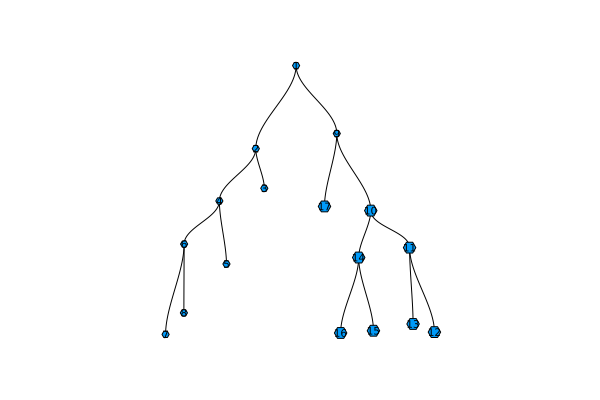

... end display. 


press enter to exit ! 


stdin>  


""

In [8]:
# Main.
instance = "InstancesKnapSack/test.opb.txt"
solveNdisplayKnap(instance)
println("press enter to exit ! ")
readline()




<div class="alert alert-info" role="alert">

## Réponses aux questions:

***Questions préliminaires***

- Quelle est la règle de séparation choisie?  
-> L'algorithme utilise une règle lexicographique statique. Il parcourt les objets dans l'ordre de leur index et choisit systématiquement le prochain objet non encore fixé, sans tenir compte de sa valeur ou de s'il est fractionnaire. 
- Quelle méthode de calcul de borne supérieure est utilisée?  
-> C'est une relaxation continue gloutonne (Dantzig) codée manuellement.
- Quels sont les tests de sondabilité TA, TO, TR?  
->  TA (Admissibilité) : Teste explicitement si capacity < 0. Si la capacité restante est négative, on coupe.  
->  TO (Optimalité) : Teste si bornesup <= BestProfit. Si la borne est inférieure ou égale au meilleur profit trouvé, on coupe.  
->  TR (Résolution/Intégrité) : Teste all( v == 0.0 || v == 1.0 for v in listVals). Si toutes les variables dans la relaxation sont entières (0 ou 1), on sauvegarde la solution si elle est meilleure, et on coupe.  
- Quelle est la stratégie d'exploration choisie?
-> C'est un parcours en profondeur (Depth First Search (DFS)). L'utilisation de la fonction pop! sur la liste des noeuds indique une structure de pile (LIFO).


***Rédaction***

- Quels points du notebook pourraient être améliorés ?  
-> Tri répété : La fonction bound_1 trie les objets à chaque appel, ce qui est extrêmement lent.  
-> Exploration naive : Le DFS lexicographique explore l'arbre à l'aveugle sans prioriser les noeuds prometteurs.  
-> Séparation : Brancher dans l'ordre 1..n est inefficace si les objets intéressants sont à la fin de la liste.

- Faites le lien avec les notions vues lors du TD 2.  
-> Comme vu en TD, l'efficacité dépend de la qualité de la borne et de la vitesse d'élagage. Une stratégie Best-First (meilleur d'abord) combinée à un branchement sur la variable la plus fractionnaire permet de trouver l'optimum beaucoup plus vite.

- Quelles pistes d’optimisation ou d’extension envisagez-vous ?  
-> Trier les objets par densité (valeur/poids) une seule fois au début de l'algorithme.  
-> Optimisation de la borne. On peut calculer la borne gloutonne en O(N) en parcourant la liste pré-triée.  
-> Utiliser une PriorityQueue pour explorer d'abord les noeuds ayant la plus forte borne supérieure. (Best-First Search)

</div>


### Code – Amélioration

In [9]:
import Pkg
Pkg.add("DataStructures")
using DataStructures

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [10]:
# Structure pour représenter un objet avec son ratio pré-calculé
struct Item
    id::Int
    weight::Float64
    value::Float64
    ratio::Float64 # ratio = value/weight
end

# Structure d'un noeud pour le Branch and Bound
struct Node
    level::Int # Profondeur dans l'arbre (index de l'objet où on est)
    current_weight::Float64 # Poids accumulé (de ce qu'on a déjà mis dans le sac)
    current_value::Float64 # Valeur accumulée
    upper_bound::Float64 # Borne supérieure calculée au noeud
    fixed_vars::Vector{Int} # Décisions prises (1=Pris ou 0=Pas Pris) pour les objets précédents
end

# Comparaison pour la PriorityQueue (On veut explorer la PLUS GRANDE upper_bound en premier)
# Comme PriorityQueue dépile le plus petit par défaut, donc on stockera -upper_bound
Base.isless(a::Node, b::Node) = a.upper_bound < b.upper_bound

"""
Fonction de calcul de la borne supérieure (Relaxation Linéaire Gloutonne)
Items doit être trié par ratio décroissant.
"""
function calculate_bound(node::Node, capacity::Float64, items::Vector{Item}, n::Int)
    if node.current_weight > capacity
        return 0.0 # Infaisable
    end

    bound = node.current_value # on commence par ce qu'on a déjà dans le sac
    tot_weight = node.current_weight
    
    # On parcourt les objets restants (après le niveau actuel du noeud) triés dans l'ordre du meilleur ratio
    for i in (node.level + 1):n
        item = items[i]
        if tot_weight + item.weight <= capacity
            # On prend l'objet en entier
            tot_weight += item.weight
            bound += item.value
        else
            # On prend la fraction restante (Relaxation continue)
            cap_rest = capacity - tot_weight
            bound += item.value * (cap_rest / item.weight)
            break # Sac plein
        end
    end
    return bound
end

"""
Algorithme Branch and Bound Amélioré
- Relaxation : Gloutonne (sans GLPK)
- Exploration : Best-First (via PriorityQueue)
- Branchement : On suit l'ordre des ratios
"""
function solve_knapsack_improved(weights, values, capacity)
    n = length(values)
    
    # Pré-traitement : Création des objets et Tri par ratio décroissant
    items = [Item(i, weights[i], values[i], values[i]/weights[i]) for i in 1:n]
    sort!(items, by = x -> x.ratio, rev = true)
    
    # Mapping inverse pour retrouver l'ordre initial des indices à la fin
    id_map = [item.id for item in items]

    # Queue de priorité pour Best-First Search
    # Pour sortir l'élément avec le plus grand upper bound, on utilisera -upper_bound comme clé.
    pq = PriorityQueue{Node, Float64}()

    # Noeud racine
    root = Node(0, 0.0, 0.0, 0.0, Int[])
    # Calcul de la borne racine
    ub_root = calculate_bound(root, capacity, items, n)
    root = Node(0, 0.0, 0.0, ub_root, Int[])
    
    enqueue!(pq, root, -ub_root) # Clé négative

    best_value = 0.0
    best_solution = zeros(Int, n)

    nodes_explored = 0

    while !isempty(pq)
        # Sélection du noeud avec la meilleure borne (Best-First)
        node = dequeue!(pq)
        nodes_explored += 1

        # Test d'optimalité
        if node.upper_bound <= best_value + 1e-6
            continue
        end

        # Si on a parcouru tous les objets (Feuille de l'arbre)
        if node.level == n
            if node.current_value > best_value
                best_value = node.current_value
                # On reconstruit la solution selon l'ordre initial
                temp_sol = zeros(Int, n)
                for (idx, val) in enumerate(node.fixed_vars)
                   temp_sol[id_map[idx]] = val
                end
                best_solution = temp_sol
            end
            continue
        end

        # Branchement
        # On passe à l'objet suivant dans la liste triée
        next_level = node.level + 1
        next_item = items[next_level]

        # Branche 1 : On prend l'objet (x = 1)
        # Test d'admissibilité (si ça rentre)
        if node.current_weight + next_item.weight <= capacity
            new_weight = node.current_weight + next_item.weight
            new_value = node.current_value + next_item.value
            
            # Création temporaire pour calcul de borne
            # fixed_vars est copié
            obj_pris = Node(next_level, new_weight, new_value, 0.0, [node.fixed_vars; 1])
            ub_pris = calculate_bound(obj_pris, capacity, items, n)
            
            if ub_pris > best_value
                obj_pris = Node(next_level, new_weight, new_value, ub_pris, obj_pris.fixed_vars)
                enqueue!(pq, obj_pris, -ub_pris)
            end
        end

        # Branche 2 : On ne prend pas l'objet (x = 0)
        obj_non_pris = Node(next_level, node.current_weight, node.current_value, 0.0, [node.fixed_vars; 0])
        ub_non_pris = calculate_bound(obj_non_pris, capacity, items, n)

        if ub_non_pris > best_value
            obj_non_pris = Node(next_level, node.current_weight, node.current_value, ub_non_pris, obj_non_pris.fixed_vars)
            enqueue!(pq, obj_non_pris, -ub_non_pris)
        end
    end

    return best_solution, best_value, nodes_explored
end

solve_knapsack_improved

### Code – Comparaison

In [11]:
using Printf # Pour un affichage propre

# Test 1 : Petite instance (validation)
w_test = [7.0, 4.0, 3.0, 5.0]
v_test = [42.0, 40.0, 12.0, 25.0]
c_test = 10.0
sol, val, nodes = solve_knapsack_improved(w_test, v_test, c_test)
println("Test Cours (Optimisé) : Valeur Attendue : 65.0 | Valeur trouvée = $val ")
println()


# Test 2 : Comparaison sur des tailles croissantes

# Wrapper pour adapter la fonction améliorée aux fichiers de l'instance
function solve_improved_from_file(filename)
    # On réutilise la fonction de lecture du TP
    price, weight, capacity = readKnaptxtInstance(filename)
    
    # On appelle la fonction améliorée
    t_start = time()
    best_sol, best_val, nodes = solve_knapsack_improved(convert(Vector{Float64}, weight), convert(Vector{Float64}, price), float(capacity))
    total_time = time() - t_start
    
    return best_val, total_time, nodes
end

println("=== DÉBUT DES TESTS DE COMPARAISON ===")
println()

#instance = "InstancesKnapSack/test.opb.txt"

fichiers_test = [
    "InstancesKnapSack/test.opb.txt",
    "InstancesKnapSack/Similar_Weights/KnapSack_100_1000_-995.opb.txt", # Similar_Weights
    "InstancesKnapSack/Strongly_Correlated/KnapSack_100_1000_-2397.opb.txt", # Strongly_Correlated
    "InstancesKnapSack/Uncorrelated/KnapSack_100_1000_-9147.opb.txt", # Uncorrelated
    "InstancesKnapSack/Weakly_Correlated/KnapSack_100_1000_-1514.opb.txt" # Weakly_Correlated
]
for instance in fichiers_test
    println(@sprintf("Fichier %s", instance))
    # Exécution de la version initiale
    t1 = time()
    val_init = -999.0 # C'est juste une valeur témoin pour etre sur qu'elle change
    try
        res = nothing 
        redirect_stdout(devnull) do 
            res = solveKnapInstance(instance) 
        end
        val_init = res[1] # On récupère la valeur
    catch e
        val_init = -1.0 # Erreur
        println("Erreur init: ", e)
    end
    t_init = time() - t1
    
    # Exécution de la version améliorée
    val_opt = 0.0
    t_opt = 0.0
    try
        # Appel via le wrapper pour la lecture du fichier
        val, t, nodes = solve_improved_from_file(instance)
        val_opt = val
        t_opt = t
        
    catch e
        println("Erreur optimisé: ", e)
    end
    
    # Affichage des résultats
    gain = t_init / t_opt
    status = (abs(val_init - val_opt) < 1e-5) ? "OK" : "DIFF!" # status indique si les deux fonctions donnent le meme résultat ou non
    
    println(@sprintf("Temps intial:   %-10.5fs", t_init))
    println(@sprintf("Temps optimisé: %-12.5fs", t_opt))
    println(@sprintf("Gain:           x%-9.1f", gain))
    println(@sprintf("Val intial:     %.0f", val_init))
    println(@sprintf("Val optimisé:   %.0f", val_opt))
    println("Status: ", status)
    println()
end

Test Cours (Optimisé) : Valeur Attendue : 65.0 | Valeur trouvée = 65.0 

=== DÉBUT DES TESTS DE COMPARAISON ===

Fichier InstancesKnapSack/test.opb.txt
Temps intial:   0.78893   s
Temps optimisé: 0.00003     s
Gain:           x30357.8  
Val intial:     65
Val optimisé:   65
Status: OK

Fichier InstancesKnapSack/Similar_Weights/KnapSack_100_1000_-995.opb.txt
Temps intial:   0.09432   s
Temps optimisé: 0.00013     s
Gain:           x742.2    
Val intial:     995
Val optimisé:   995
Status: OK

Fichier InstancesKnapSack/Strongly_Correlated/KnapSack_100_1000_-2397.opb.txt
Temps intial:   1510.53020s
Temps optimisé: 0.00238     s
Gain:           x635723.7 
Val intial:     2397
Val optimisé:   2397
Status: OK

Fichier InstancesKnapSack/Uncorrelated/KnapSack_100_1000_-9147.opb.txt
Temps intial:   97.95406  s
Temps optimisé: 0.00204     s
Gain:           x48041.3  
Val intial:     9147
Val optimisé:   9147
Status: OK

Fichier InstancesKnapSack/Weakly_Correlated/KnapSack_100_1000_-1514.opb.txt


### Résultats :

Test Cours (Optimisé) : Valeur Attendue : 65.0 | Valeur trouvée = 65.0 

=== DÉBUT DES TESTS DE COMPARAISON ===

Fichier InstancesKnapSack/test.opb.txt  
Temps intial:   0.78893   s  
Temps optimisé: 0.00003     s  
Gain:           x30357.8    
Val intial:     65  
Val optimisé:   65  
Status: OK  

Fichier InstancesKnapSack/Similar_Weights/KnapSack_100_1000_-995.opb.txt  
Temps intial:   0.09432   s  
Temps optimisé: 0.00013     s  
Gain:           x742.2    
Val intial:     995  
Val optimisé:   995  
Status: OK  

Fichier InstancesKnapSack/Strongly_Correlated/KnapSack_100_1000_-2397.opb.txt  
Temps intial:   1510.53020s  
Temps optimisé: 0.00238     s  
Gain:           x635723.7   
Val intial:     2397  
Val optimisé:   2397  
Status: OK  

Fichier InstancesKnapSack/Uncorrelated/KnapSack_100_1000_-9147.opb.txt  
Temps intial:   97.95406  s  
Temps optimisé: 0.00204     s  
Gain:           x48041.3    
Val intial:     9147  
Val optimisé:   9147  
Status: OK  

Fichier InstancesKnapSack/Weakly_Correlated/KnapSack_100_1000_-1514.opb.txt  
Temps intial:   9.34456   s  
Temps optimisé: 0.00350     s  
Gain:           x2671.3     
Val intial:     1514  
Val optimisé:   1514  
Status: OK  


## Discussion :
On observe un gain de performance massif (x1000 à x10^6). Cela est cohérent car la version initiale retriait le tableau à chaque noeud (complexité O(nlogn) à chaque étape) alors que nous ne le faisons qu'une fois. De plus, la stratégie Best-First permet de trouver une excellente solution très vite, ce qui rend le test d'optimalité (TO) beaucoup plus efficace pour couper les branches inutiles, surtout sur les instances 'Strongly Correlated'.
